# Introduction

The aim of this project is to perform Exploratory Data Analysis (EDA) on the House Prices dataset. The analysis includes data inspection, cleaning, visualization, correlation analysis, and extracting insights that can support future machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:
housing = pd.read_csv("Housing.csv")

In [3]:
housing.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
print("Housing:", housing.shape)

Housing: (545, 13)


In [6]:
housing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
print(housing.duplicated().sum())

0


In [ ]:
# Summary:
# The House Prices dataset contains 545 observations and 13 features,
# consisting of numerical and categorical variables.
# No missing values or duplicate records were identified,
# indicating that the dataset is generally clean and ready for analysis.
# Only minor preprocessing, such as verifying data types, is required.

# Data Cleaning

In [8]:
housing_clean = housing.copy()

In [19]:
categorical_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

for col in categorical_columns:
    housing_clean[col] = housing_clean[col].astype("category")

In [10]:
# Verify data quality
print("\nHousing Missing Values After Cleaning:")
print(housing_clean.isnull().sum())

print("\nHousing Duplicate Records:")
print(housing_clean.duplicated().sum())


Housing Missing Values After Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Housing Duplicate Records:
0


In [20]:
# Data Cleaning Decisions:
# - Confirmed there were no missing values, so no imputation was required.
# - No duplicated records.
# - Converted categorical variables to the category data type for consistency and efficiency.
# - Verified the cleaned dataset contained no unnecessary missing values or duplicates.

# Exploratory Data Analysis (EDA)

In [28]:
# Cleaned Dataset

housing_clean.to_csv("Housing_Cleaned.csv", index=False)

housing = pd.read_csv("Housing_Cleaned.csv")

housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Univariate Analysis

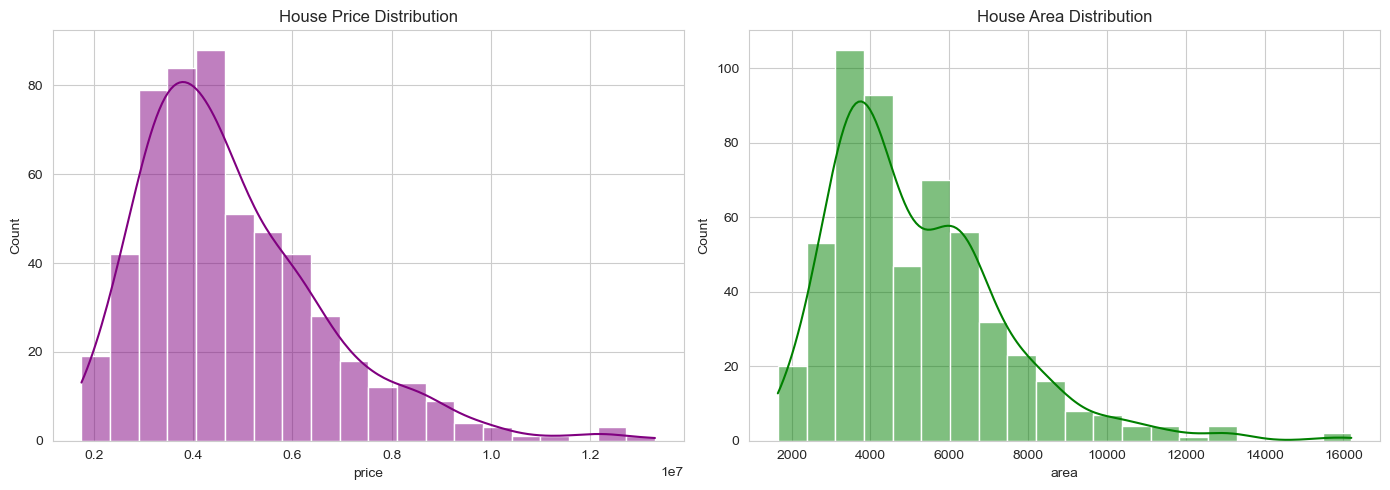

In [22]:
# Histogram showing house price and area distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=housing,
    x="price",
    bins=20,
    kde=True,
    color="purple",
    ax=axes[0]
)
axes[0].set_title("House Price Distribution")

sns.histplot(
    data=housing,
    x="area",
    bins=20,
    kde=True,
    color="green",
    ax=axes[1]
)
axes[1].set_title("House Area Distribution")

plt.tight_layout()
plt.show()

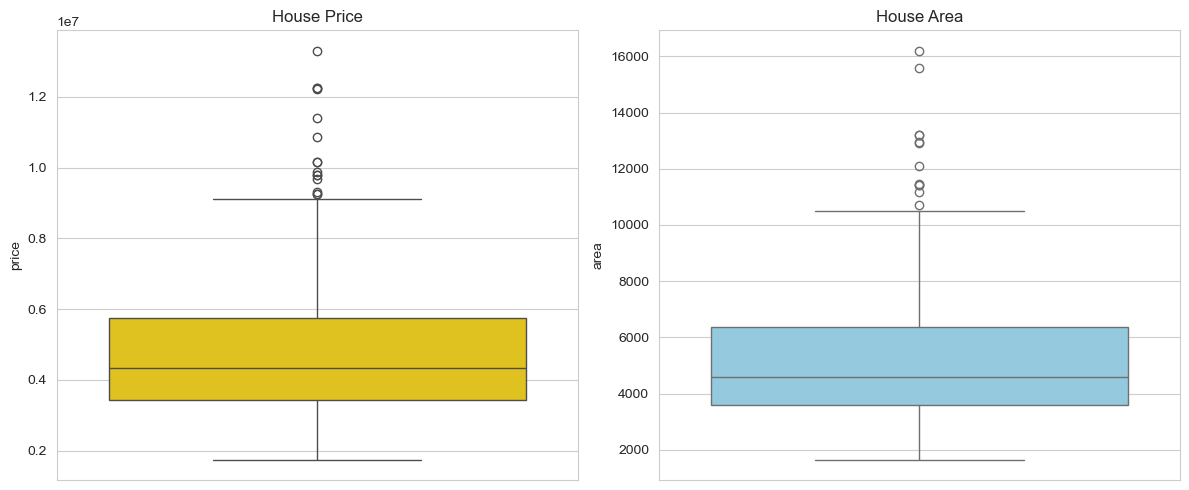

In [23]:
# Boxplot showing house price and area

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=housing,
    y="price",
    color="gold",
    ax=axes[0]
)
axes[0].set_title("House Price")

sns.boxplot(
    data=housing,
    y="area",
    color="skyblue",
    ax=axes[1]
)
axes[1].set_title("House Area")

plt.tight_layout()
plt.show()

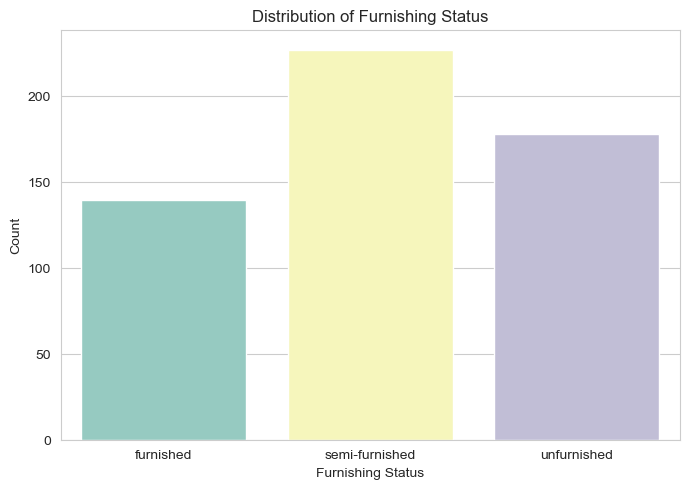

In [24]:
# A bar chart of the furnishing status

plt.figure(figsize=(7, 5))

sns.countplot(
    data=housing,
    x="furnishingstatus",
    hue="furnishingstatus",
    palette="Set3",
    legend=False
)

plt.title("Distribution of Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Univariate Analysis Summary:
# - Price and Area have the highest variation, indicating a wide range of property values and sizes.
# - Outliers are present in both Price and Area, suggesting the presence of luxury or unusually large properties.
# - Semi-furnished houses are the most common furnishing category.

### Bivariate Analysis

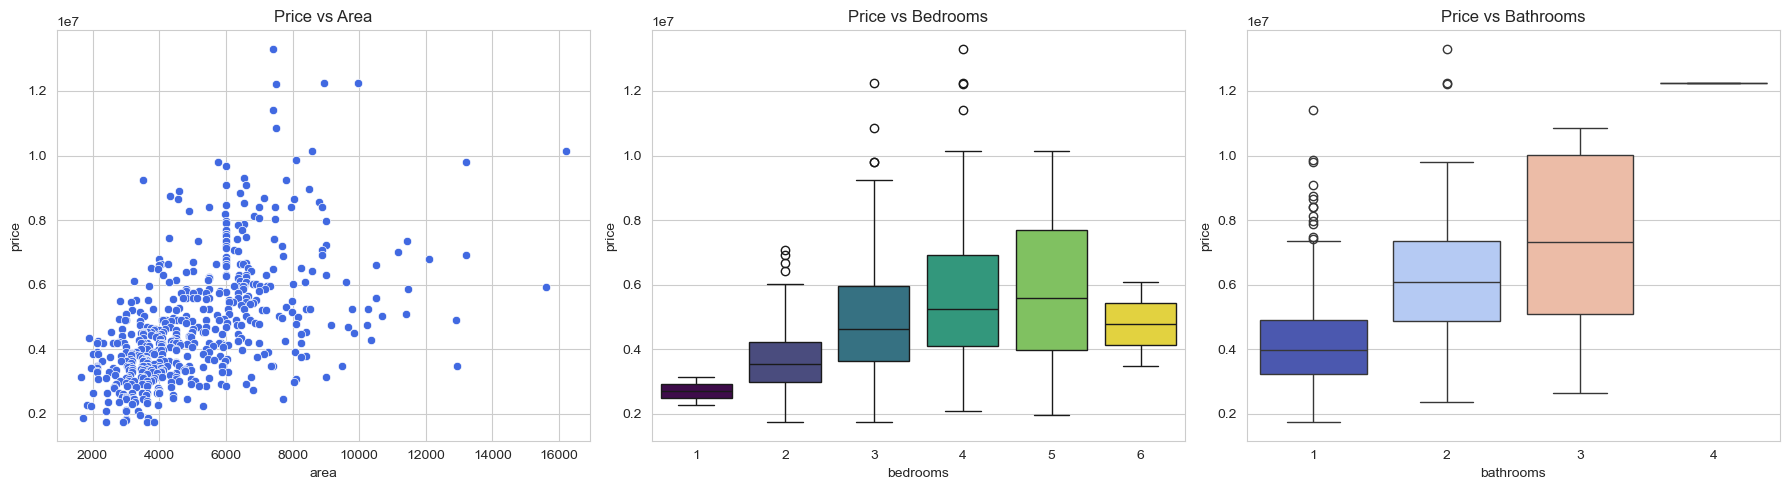

In [25]:
# Price Relationships

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=housing,
    x="area",
    y="price",
    color="royalblue",
    ax=axes[0]
)
axes[0].set_title("Price vs Area")

sns.boxplot(
    data=housing,
    x="bedrooms",
    y="price",
    hue="bedrooms",
    palette="viridis",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Price vs Bedrooms")

sns.boxplot(
    data=housing,
    x="bathrooms",
    y="price",
    hue="bathrooms",
    palette="coolwarm",
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Price vs Bathrooms")

plt.tight_layout()
plt.show()

In [ ]:
# Bivariate Analysis Summary:
# - Area, Bathrooms, and Bedrooms appear to have the greatest influence on house prices.
# - House prices generally increase as the area, number of bedrooms, and bathrooms increase.
# - Area shows the strongest positive relationship with price among the variables analyzed.

### Correlation and Feature Importance

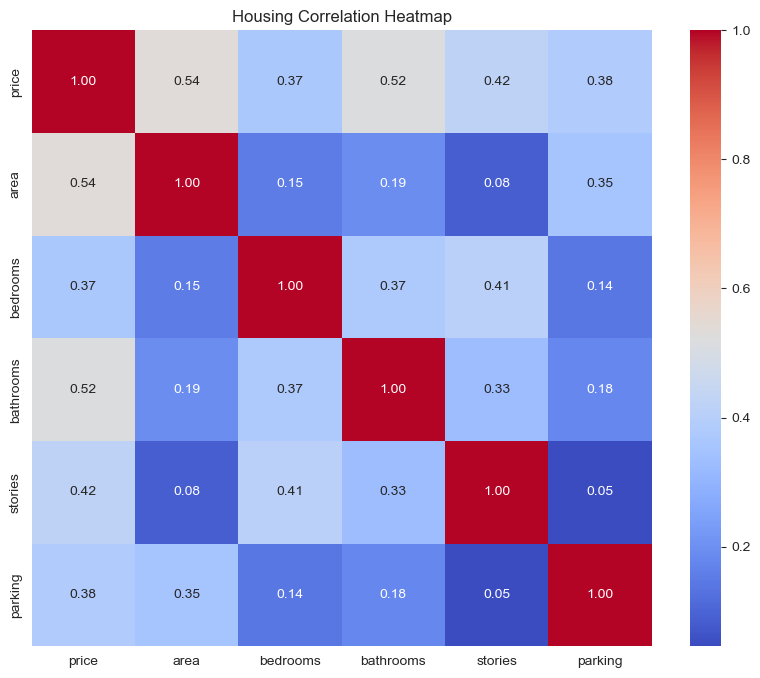

In [26]:
#Housing Correlation Map

plt.figure(figsize=(10, 8))

sns.heatmap(
    housing.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.,
    fmt=".2f"
)

plt.title("Housing Correlation Heatmap")
plt.show()

In [18]:
# area, bathrooms, and stories are among the strongest predictors of house price.
# These features should be prioritized when building a house price prediction model.